# Sample Model
We here introduce the SampleModel, ResolutionModel and BackgroundModel, which all function in a similar way. They are, as the name implies, used to describe scattering from the sample, the resolution function and the background, respectively.

The models describe the scattering from the sample as function of ${\bf Q}$ and $E$. This is done by generating ComponentCollection's for each ${\bf Q}$, where each ComponentCollection contains a collection of ModelComponents such as Gaussians and Lorentzians. The model can be given a single template component or a collection of components that will be copied to each ${\bf Q}$

We further support various models of diffusion, which typically generate one or more Lorentzian components, where the width (and usually the area) has a particular dependence on $Q$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import easydynamics.sample_model as sm

%matplotlib widget

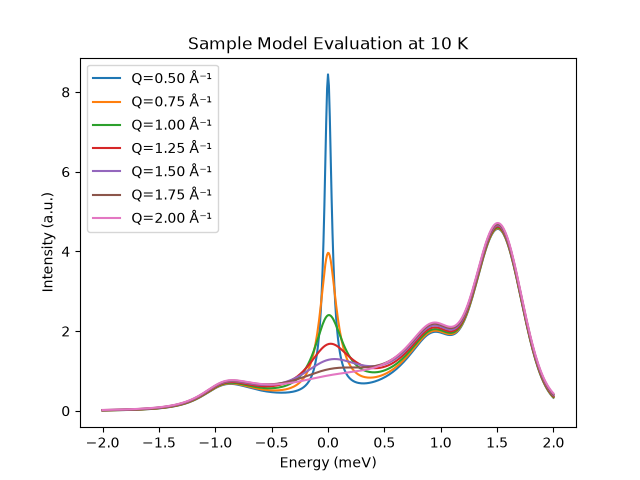

In [2]:
# Create a diffusion_model and components for the SampleModel
Q = np.linspace(0.5, 2, 7)
energy = np.linspace(-2, 2, 501)

scale = 1.0
diffusion_coefficient = 2.4e-9  # m^2/s
diffusion_model = sm.BrownianTranslationalDiffusion(
    display_name='DiffusionModel',
    scale=scale,
    diffusion_coefficient=diffusion_coefficient,
)


# Creating components
component_collection = sm.ComponentCollection()
gaussian = sm.Gaussian(display_name='Gaussian', width=0.2, area=1, center=1.5)
dho = sm.DampedHarmonicOscillator(display_name='DHO', center=1.0, width=0.3, area=2.0)

# Adding components to the component collection
component_collection.append_component(gaussian)
component_collection.append_component(dho)

sample_model = sm.SampleModel(
    diffusion_models=diffusion_model,
    components=component_collection,
    Q=Q,
    x_unit='meV',
    display_name='MySampleModel',
    temperature=10,
)

# Calculate the model intensity at the specified Q and energy values
# y_list will be a list of intensity arrays, one for each Q value
sample_intensity = sample_model.evaluate(energy)

plt.figure()
for i, Q_value in enumerate(Q):
    plt.plot(energy, sample_intensity[i], label=f'Q={Q_value:.2f} Å⁻¹')
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (a.u.)')
plt.title('Sample Model Evaluation at 10 K')
plt.legend()
plt.show()

In [3]:
# Create a BackgroundModel and show other ways to set Q and components

background_model = sm.BackgroundModel()
background_model.Q = Q

background_model.components = sm.Polynomial(coefficients=[1, 0.1, 0.01])
background = background_model.evaluate(energy)

# Also create a ResolutionModel.
# It doesn't do anything here, but shows how to set it up.
resolution_model = sm.ResolutionModel()
resolution_model.Q = Q
resolution_model.append_component(sm.Gaussian(width=0.05))
resolution = resolution_model.evaluate(energy)

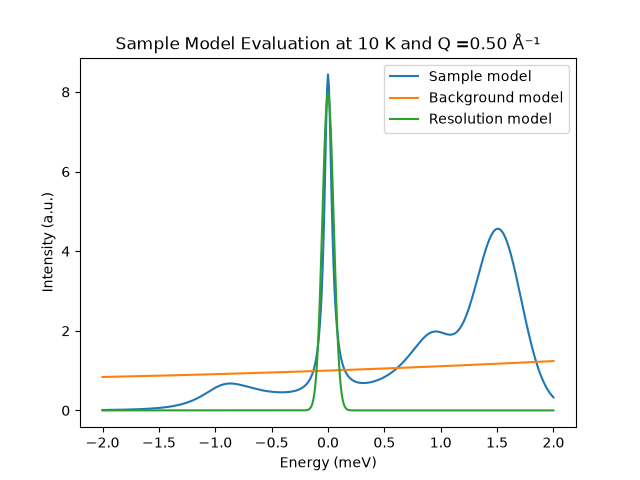

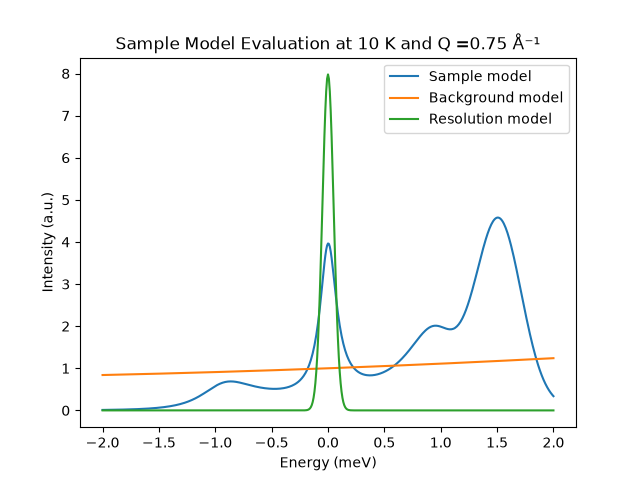

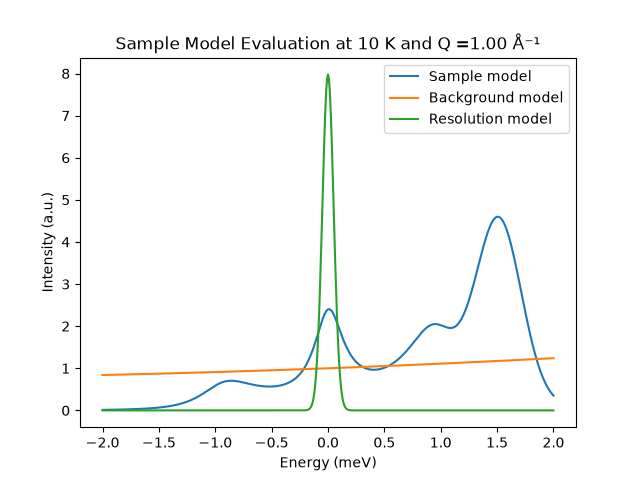

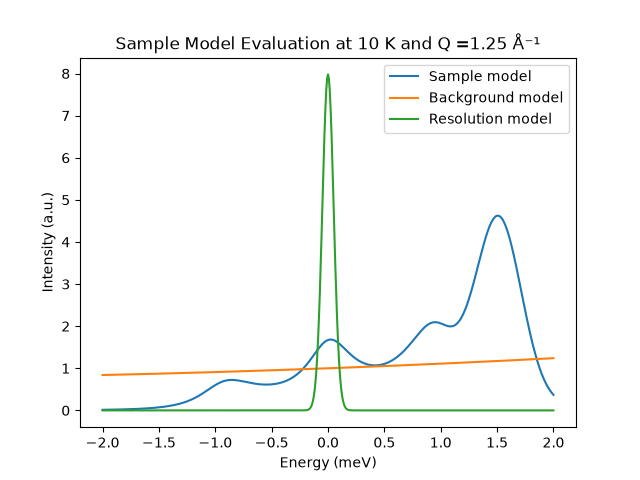

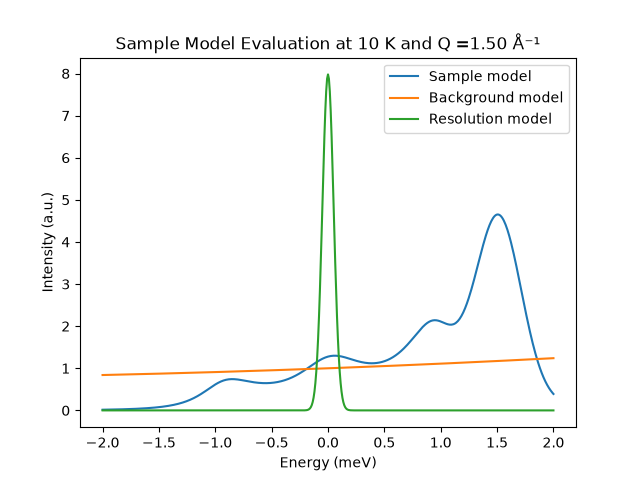

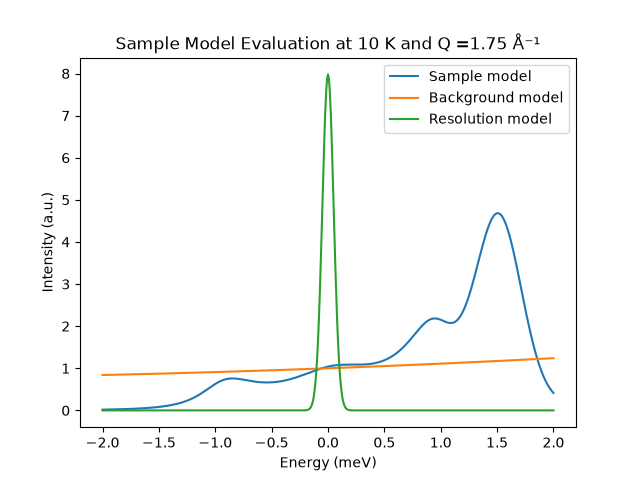

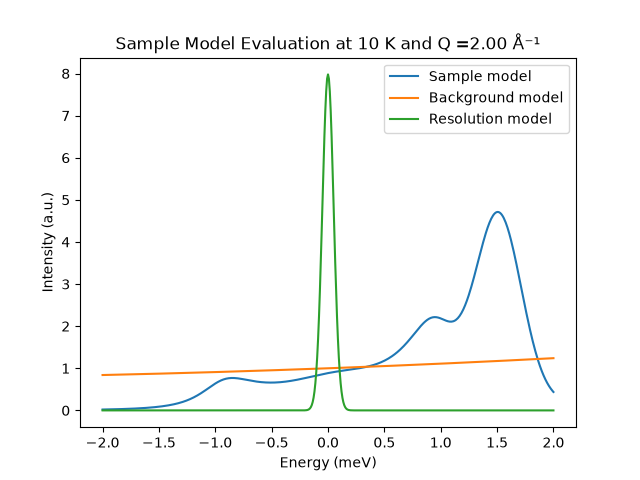

In [4]:
# Plot the three models together
for i, Q_value in enumerate(Q):
    plt.figure()
    plt.plot(energy, sample_intensity[i], label='Sample model')
    plt.plot(energy, background[i], label='Background model')
    plt.plot(energy, resolution[i], label='Resolution model')
    plt.legend()
    plt.xlabel('Energy (meV)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(f'Sample Model Evaluation at 10 K and Q ={Q_value:.2f} Å⁻¹')
    plt.legend()
    plt.show()